# Task 1: Potential Problems in Linear Regression
This notebook explores three common problems that arise when fitting a linear regression model **outliers**, **high-leverage points**, and **collinearity**, and use generative AI to explore examples that illustrate these problems. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100

## Issue 1: Outliers
An **outlier** in regression is an observation whose response value $y_i$ is unusually far from the value predicted by the fitted model that is, it has a large residual. Outliers matter because, while a single extreme point may not dramatically shift the fitted line in all cases, it *will* inflate the residual standard error (RSE), which directly harms hypothesis tests, confidence intervals, and model fit statistics like $R^2$. The standard tool for detection is the **studentized residual**: each raw residual is divided by an estimate of its standard deviation. Observations with a studentized residual greater than 3 in absolute value are flagged as potential outliers. Once identified, the analyst should investigate whether the point reflects a data-entry error (fix or remove it), a genuine extreme event (keep it but report it), or evidence that the model is misspecified (revisit the model).

### Question investigated

**Q: Why do studentized residuals have a consistent $\pm3$ threshold regardless of the scale of $y$, rather than raw residuals?**

**A:** Raw residuals are measured in the same units as $y$, so a "large" residual depends entirely on the variance of the data. Studentized residuals divide each residual by an estimate of its own standard deviation (computed from a model fit with that point *deleted*), producing a $t$-distributed statistic with mean 0 and variance of about 1. Because this normalization removes the scale of $y$, the $\pm3$ cutoff is meaningful across all datasets, it corresponds roughly to the 99.7% region of a standard normal, so values beyond it are genuinely surprising under the model.

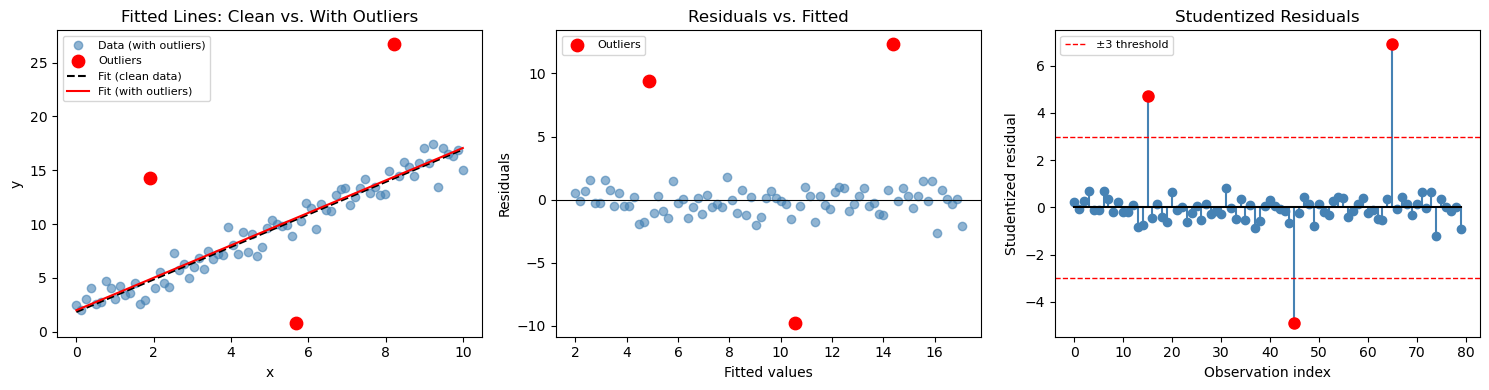

In [2]:
# --- Synthetic data: clean linear relationship with a few injected outliers ---
n = 80
x = np.linspace(0, 10, n)
y_clean = 2 + 1.5 * x + np.random.normal(0, 1, n)

y_outlier = y_clean.copy()
outlier_idx = [15, 45, 65]
y_outlier[outlier_idx] += [10, -9, 11]

X_sm = sm.add_constant(x)
model_clean   = sm.OLS(y_clean,   X_sm).fit()
model_outlier = sm.OLS(y_outlier, X_sm).fit()

influence  = OLSInfluence(model_outlier)
stud_resid = influence.resid_studentized_external

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.scatter(x, y_outlier, color='steelblue', alpha=0.6, label='Data (with outliers)')
ax.scatter(x[outlier_idx], y_outlier[outlier_idx], color='red', zorder=5, s=80, label='Outliers')
ax.plot(x, model_clean.fittedvalues,   'k--', label='Fit (clean data)')
ax.plot(x, model_outlier.fittedvalues, 'r-',  label='Fit (with outliers)')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Fitted Lines: Clean vs. With Outliers')
ax.legend(fontsize=8)

ax = axes[1]
ax.scatter(model_outlier.fittedvalues, model_outlier.resid, color='steelblue', alpha=0.6)
ax.scatter(model_outlier.fittedvalues[outlier_idx], model_outlier.resid[outlier_idx],
           color='red', zorder=5, s=80, label='Outliers')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Fitted values'); ax.set_ylabel('Residuals')
ax.set_title('Residuals vs. Fitted')
ax.legend(fontsize=8)

ax = axes[2]
ax.stem(np.arange(n), stud_resid, linefmt='steelblue', markerfmt='o', basefmt='k-')
ax.axhline( 3, color='red', linestyle='--', linewidth=1, label='±3 threshold')
ax.axhline(-3, color='red', linestyle='--', linewidth=1)
for i in outlier_idx:
    ax.plot(i, stud_resid[i], 'ro', markersize=8, zorder=5)
ax.set_xlabel('Observation index')
ax.set_ylabel('Studentized residual')
ax.set_title('Studentized Residuals')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Figure Caption:** The left panel overlays the regression line fitted to clean data (dashed black) versus the line fitted when three outliers are present (solid red); the outliers visibly pull the fitted line. The middle panel shows that the outlier observations (red dots) produce residuals that stand out clearly from the rest. The right panel plots studentized residuals against observation index: the three injected outliers are the only points beyond the $\pm3$ threshold (red dashed lines), demonstrating that studentized residuals reliably flag anomalous observations. The fourth panel shows that the green line (outliers removed) closely recovers the original clean it (dashed black), confirming that removing the flagged observations resolves the distortion.

## Issue 2: High-Leverage Points
A **high-leverage point** is an observation with an unusual value of the predictor $x_i$ (or unusual combination of predictors in multiple regression), regardless of where its response $y_i$ falls. High-leverage points tend to have a sizable impact on the estimated regression line, so it is important to identify them. For simple linear regression, leverage is quantified by the leverage statistic:

$$h_i = \frac{1}{n} + \frac{(x_i - \bar{x})^2}{\sum_{i'=1}^{n}(x_{i'} - \bar{x})^2}$$

It is clear from this equation that $h_i$ increases with the distance of $x_i$ from $\bar{x}$. The statistic is always between $1/n$ and $1$, and the average leverage across all observations equals $(p+1)/n$. An observation whose $h_i$ greatly exceeds $(p+1)/n$ is flagged as high leverage. A particularly dangerous combination arises when a point has both high leverage *and* a large studentized residual — it is simultaneously unusual in $x$ and in y$, and can heavily distort the fitted line.

### Question investigated

**Q: The textbook says an observation can fall within the normal range of each individual predictor yet still have high leverage in multiple regression, why does this happen?**

**A:** In simple linear regression, "unusual x" is one-dimensional, so it is easy to spot by just looking at the range of x values. In multiple regression, the predictors have a *joint* distribution that is typically not a imple box, if x1 and x2 are correlated, the observations cluster along an ellipse (as in Figure 3.13 of the textbook), not a rectangle. A point can sit inside the marginal range of x1 and inside the marginal range of x2, yet till land far outside this ellipse, in a region of predictor space that no other observation occupies. Because it is isolated in the full joint space, the regression line has no nearby points to "anchor" it, giving that bservation outsized influence on the fit. The leverage statistic $h_i$ captures this because it measures distance in the full predictor space simultaneously, not predictor-by-predictor.

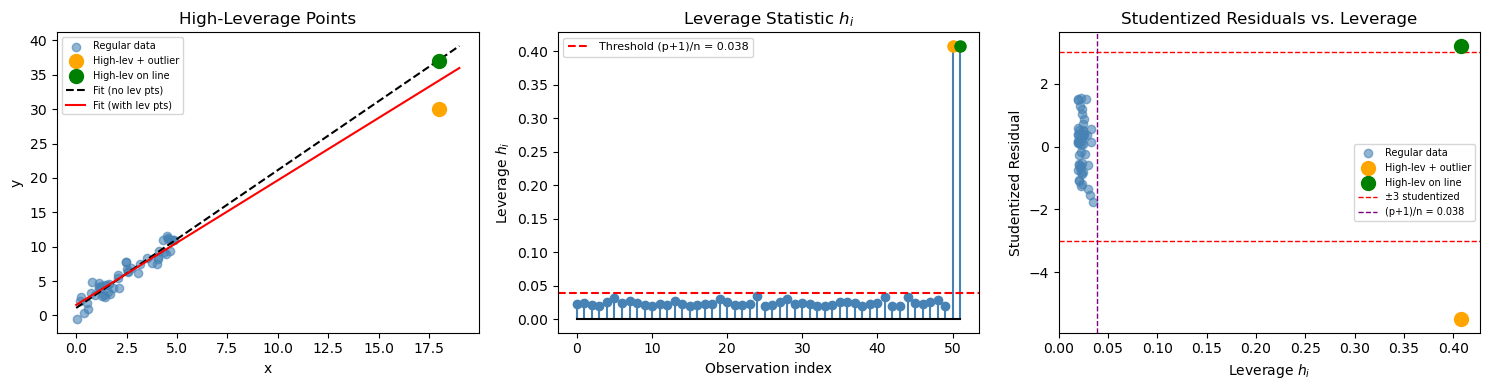

In [3]:
# --- Synthetic data: leverage illustration ---
n = 50
x_lev = np.random.uniform(0, 5, n)
y_lev = 1 + 2 * x_lev + np.random.normal(0, 1, n)

# Add one high-leverage + outlier (orange) and one high-leverage on the line (green)
x_lev = np.append(x_lev, [18,  18  ])
y_lev = np.append(y_lev, [30,  37  ])   # 1 + 2*18 = 37 is "on the line"

X_lev = sm.add_constant(x_lev)
model_lev   = sm.OLS(y_lev, X_lev).fit()
model_nolev = sm.OLS(y_lev[:-2], sm.add_constant(x_lev[:-2])).fit()

infl = OLSInfluence(model_lev)
leverage   = infl.hat_matrix_diag
stud_resid = infl.resid_studentized_external
lev_thresh = 2 / len(x_lev)   # (p+1)/n, p=1

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: scatter + fits
ax = axes[0]
ax.scatter(x_lev[:-2], y_lev[:-2], color='steelblue', alpha=0.6, label='Regular data')
ax.scatter(x_lev[-2], y_lev[-2], color='orange', s=100, zorder=5, label='High-lev + outlier')
ax.scatter(x_lev[-1], y_lev[-1], color='green',  s=100, zorder=5, label='High-lev on line')
x_range = np.linspace(0, 19, 200)
b0_full, b1_full = model_lev.params
b0_no,   b1_no   = model_nolev.params
ax.plot(x_range, b0_no   + b1_no   * x_range, 'k--', label='Fit (no lev pts)')
ax.plot(x_range, b0_full + b1_full * x_range, 'r-',  label='Fit (with lev pts)')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('High-Leverage Points')
ax.legend(fontsize=7)

# Plot 2: leverage statistic
ax = axes[1]
ax.stem(np.arange(len(x_lev)), leverage, linefmt='steelblue', markerfmt='o', basefmt='k-')
ax.axhline(lev_thresh, color='red', linestyle='--',
           label=f'Threshold (p+1)/n = {lev_thresh:.3f}')
ax.plot(len(x_lev)-2, leverage[-2], 'o', color='orange', markersize=8, zorder=5)
ax.plot(len(x_lev)-1, leverage[-1], 'o', color='green',  markersize=8, zorder=5)
ax.set_xlabel('Observation index')
ax.set_ylabel('Leverage $h_i$')
ax.set_title('Leverage Statistic $h_i$')
ax.legend(fontsize=8)

# Plot 3: studentized residuals vs leverage (Figure 3.13 style)
ax = axes[2]
ax.scatter(leverage[:-2], stud_resid[:-2], color='steelblue', alpha=0.6, label='Regular data')
ax.scatter(leverage[-2], stud_resid[-2], color='orange', s=100, zorder=5, label='High-lev + outlier')
ax.scatter(leverage[-1], stud_resid[-1], color='green',  s=100, zorder=5, label='High-lev on line')
ax.axhline( 3, color='red', linestyle='--', linewidth=1, label='±3 studentized')
ax.axhline(-3, color='red', linestyle='--', linewidth=1)
ax.axvline(lev_thresh, color='purple', linestyle='--', linewidth=1,
           label=f'(p+1)/n = {lev_thresh:.3f}')
ax.set_xlabel('Leverage $h_i$')
ax.set_ylabel('Studentized Residual')
ax.set_title('Studentized Residuals vs. Leverage')
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

**Figure 2:**  Two high-leverage points are added at $x = 18$, far beyond the bulk of the data (0–5); by the textbook formula, their $h_i$ values are large because $(x_i - \bar{x})^2$ is large relative to the spread of he other observations. The left panel shows that the orange point (high leverage + outlier) pulls the fitted line (red) away from the baseline (dashed black), while the green point (high leverage, on the line) barely changes it. The middle panel confirms both added points exceed the $(p+1)/n$ threshold, and the right panel shows that only the orange point has a large Cook's distance, confirming the textbook's warning that high leverage combined with a large studentized residual is a particularly dangerous combination.

## Issue 3: Collinearity
**Collinearity** (or multicollinearity) refers to a situation in which two or more predictor variables are closely linearly related to each other. This is a problem because the OLS algorithm cannot cleanly attribute variation in $y$ to one predictor versus the other: any number of coefficient combinations can produce nearly the same fitted values, making the estimates unstable (high variance). Concretely, collinearity inflates the standard errors of the affected coefficients, causing $t$-statistics to shrink and making it easy to miss effects that are genuinely present, a form of reduced statistical power. The simplest detection tool for two predictors is the **correlation matrix**; for multiple predictors the preferred measure is the **Variance Inflation Factor (VIF)**, where $\text{VIF}(\hat{\beta}_j) = 1/(1 - R^2_j)$ and $R^2_j$ is obtained by regressing $X_j$ on all other predictors. A VIF above 5–10 signals a problematic level of collinearity. Recommended remedies are to drop one of the collinear variables from the regression, since the removed variable's information is redundant given the other or to combine the collinear variables into a single predictor, such as an average of their standardized versions.

### Question investigated

**Q: If two predictors are collinear, why doesn't it affect predictions, only inference?**

**A:** When collinear predictors are both included, the model can still fit the training data well because the two predictors together span the relevant direction in predictor space, even if they cannot be separated individually. What collinearity destroys is our ability to estimate each coefficient separately with precision — the estimates have huge variance, but their weighted combination may still be estimated accurately. This means in-sample and even out-of-sample predictions (for test points that preserve the same collinear structure) can remain accurate, while individual coefficient estimates and their standard errors are unreliable. The problem becomes severe for predictions only when a new observation does *not* preserve the collinear relationship seen in training data.

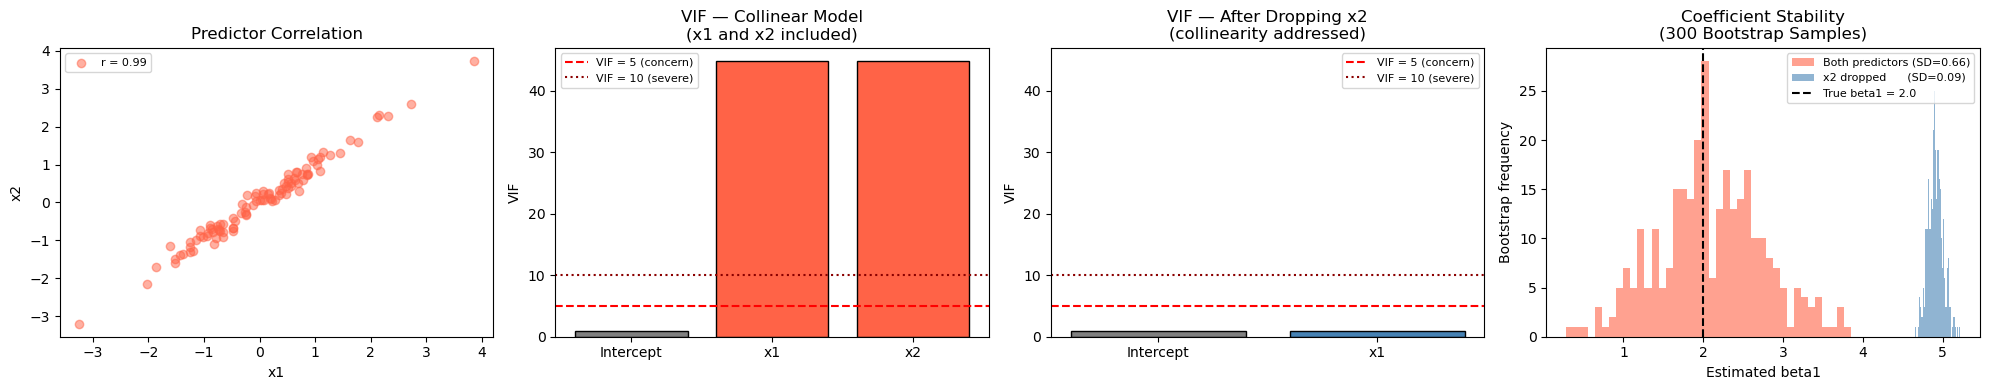

In [4]:
# --- Synthetic data: collinearity ---
n = 100
x1 = np.random.normal(0, 1, n)

x2_collinear   = 0.98 * x1 + np.random.normal(0, 0.2, n)   # r ≈ 0.98
x2_independent = np.random.normal(0, 1, n)                  # control case

true_beta1, true_beta2 = 2.0, 3.0
y = true_beta1 * x1 + true_beta2 * x2_collinear + np.random.normal(0, 1, n)

X_col = sm.add_constant(np.column_stack([x1, x2_collinear]))
X_ind = sm.add_constant(np.column_stack([x1, x2_independent]))
X_drop = sm.add_constant(x1)   # x2 dropped — address collinearity
model_col  = sm.OLS(y, X_col).fit()
model_drop = sm.OLS(y, X_drop).fit()

vif_col  = [variance_inflation_factor(X_col,  i) for i in range(X_col.shape[1])]
vif_drop = [variance_inflation_factor(X_drop, i) for i in range(X_drop.shape[1])]

# Bootstrap coefficient distributions
n_boot = 300
beta1_col_boot, beta1_drop_boot = [], []
for _ in range(n_boot):
    idx = np.random.choice(n, n, replace=True)
    Xc = sm.add_constant(np.column_stack([x1[idx], x2_collinear[idx]]))
    Xd = sm.add_constant(x1[idx])
    yb = y[idx]
    beta1_col_boot.append(sm.OLS(yb, Xc).fit().params[1])
    beta1_drop_boot.append(sm.OLS(yb, Xd).fit().params[1])

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# Plot 1: predictor scatter showing collinearity
ax = axes[0]
ax.scatter(x1, x2_collinear, alpha=0.5, color='tomato',
           label=f'r = {np.corrcoef(x1, x2_collinear)[0,1]:.2f}')
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('Predictor Correlation')
ax.legend(fontsize=8)

# Plot 2: VIF with both collinear predictors
ax = axes[1]
ax.bar(['Intercept', 'x1', 'x2'], vif_col,
       color=['gray', 'tomato', 'tomato'], edgecolor='black')
ax.axhline(5,  color='red',     linestyle='--', label='VIF = 5 (concern)')
ax.axhline(10, color='darkred', linestyle=':',  label='VIF = 10 (severe)')
ax.set_ylabel('VIF')
ax.set_title('VIF — Collinear Model\n(x1 and x2 included)')
ax.legend(fontsize=8)

# Plot 3: VIF after dropping x2
ax = axes[2]
ax.bar(['Intercept', 'x1'], vif_drop,
       color=['gray', 'steelblue'], edgecolor='black')
ax.axhline(5,  color='red',     linestyle='--', label='VIF = 5 (concern)')
ax.axhline(10, color='darkred', linestyle=':',  label='VIF = 10 (severe)')
ax.set_ylim(0, max(vif_col) * 1.05)   # same y-axis for direct comparison
ax.set_ylabel('VIF')
ax.set_title('VIF — After Dropping x2\n(collinearity addressed)')
ax.legend(fontsize=8)

# Plot 4: bootstrap showing coefficient stability improvement
ax = axes[3]
ax.hist(beta1_col_boot,  bins=40, alpha=0.6, color='tomato',
        label=f'Both predictors (SD={np.std(beta1_col_boot):.2f})')
ax.hist(beta1_drop_boot, bins=40, alpha=0.6, color='steelblue',
        label=f'x2 dropped      (SD={np.std(beta1_drop_boot):.2f})')
ax.axvline(true_beta1, color='black', linestyle='--', label=f'True beta1 = {true_beta1}')
ax.set_xlabel('Estimated beta1')
ax.set_ylabel('Bootstrap frequency')
ax.set_title('Coefficient Stability\n(300 Bootstrap Samples)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Figure 3:** The first panel confirms the near-perfect linear relationship between $x_1$ and $x_2$ ($r \approx 0.98$). The second panel shows that both predictors have VIFs well above the 5–10 threshold when both are included in the model, indicating severe collinearity. The third panel shows the fix: after dropping $x_2$, the VIF for $x_1$ falls to approximately 1, the minimum possible value indicating no collinearity, consistent with the textbook's observation that dropping a collinear variable rarely compromises the fit since its information is redundant. The fourth panel shows the direct benefit: bootstrapped estimates of $\hat{\beta}_1$ are widely spread when both predictors are included (red) but tightly concentrated around the true value after dropping $x_2$ (blue), demonstrating the improvement in coefficient stability.


## Generative AI Reflection
I used **Claude (claude.ai)** to write all three code blocks in this notebook. For each issue I gave a single prompt asking it to generate synthetic data illustrating the problem, fit the appropriate models using statsmodels, and produce three side-by-side plots that make the issue visually clear. Several corrections were made through follow-up prompts: the leverage threshold was initially written as $2(p+1)/n$ instead of $(p+1)/n$ from the extbook, the third leverage plot used Cook's distance which does not appear in the textbook and was replaced with a studentized residuals vs. $h_i$ scatter plot matching Figure 3.13, the leverage formula initially referenced the hat matrix rather than the formula given in the textbook, the collinearity section was missing a plot showing how to address the issue and a fourth plot was added comparing VIFs before and after dropping the collinear variable, and before/after plot was added to the outliers section showing that removing flagged observations recovers the clean fitted line. Each correction was identified by cross-referencing the generated code and explanations against the textbook reading.